In [4]:
import pandas as pd 
import numpy as np 

print("All packages imported successfully!")
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

All packages imported successfully!
Pandas version: 3.0.3
Numpy version: 2.4.6


In [ ]:
import pandas as pd
import numpy as np

# Day 3
# Creating a DataFrame from a dictionary

data = {
    'student_name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'hours_studied': [5, 8, 3, 10, None],
    'Previous_score': [65, 85, 55, 92, 95],
    'attendance': [80, 90, 70, 95, np.nan],
    'sleep_hours': [7.5, 8.0, 6.0, 9.0, "NA"],
    'extracurricular': ['yes', 'no', 'yes', 'yes', 'no'],
    'Parent_education': ['Bachelor', 'Master', 'Highschool', 'PhD', 'Bachelor']
}

df = pd.DataFrame(data)

print("Student Performance DataFrame:")
print(df)

print("\nData Info:")
df.info()

print("\nDataFrame Shape:", df.shape[0], "rows", df.shape[1], "columns")
print("Column Names:", df.columns.tolist())
print("Data Types:\n", df.dtypes)

#view data 

print("first 3 rows:")
print(df.head(3))

print("last 2 rows:")
print(df.tail(2))

#statistical memory
print("\n statistical memory") #mean median mode
print(df.describe())

#check for missing values
print("\n Missing values:")
print(df.isnull().sum())

#information about dataframe
print("\n Dataframe info:")
df.info()

# Check NaN values
print("\nCheck for NaN values:")
print(df.isnull())

#check on duplicates rows
print("\n Duplicate Rows: ")
print(df.duplicated().sum())

#selecting columns
print("Selecting single column:")
print(df['student_name'])

print("\n Selecting Multiple columns:")
print(df[['student_name','hours_studied','attendance']])

# Filtering rows
print("\nStudents who studied more than 6 hours:")
high_studiers = df[df['hours_studied'] > 6]
print(high_studiers)

print("\nStudents with attendance > 85%:")
good_attendance = df[df['attendance'] > 85]
print(good_attendance)

# Multiple conditions
print("\nExcellent students (study > 6h AND attendance > 85%):")
excellent = df[(df['hours_studied'] > 6) & (df['attendance'] > 85)]
print(excellent)

# Add new calculated columns
df['total_study_effort'] = df['hours_studied'] * (df['attendance'] / 100)
df['sleep_quality'] = df['sleep_hours'] / 8  # Normalized to 8 hours

# Add a grade column based on previous_score (for demonstration)
def calculate_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['grade'] = df['previous_score'].apply(calculate_grade)

print("DataFrame with new columns:")
print(df)

# Using map for categorical conversion
df['extracurricular_num'] = df['extracurricular'].map({'Yes': 1, 'No': 0})
print("\nCategorical columns converted to numbers:")
print(df[['student_name', 'extracurricular', 'extracurricular_num']])



Student Performance DataFrame:
  student_name  hours_studied  Previous_score  attendance sleep_hours  \
0        Alice            5.0              65        80.0         7.5   
1          Bob            8.0              85        90.0         8.0   
2      Charlie            3.0              55        70.0         6.0   
3        Diana           10.0              92        95.0         9.0   
4          Eve            NaN              95         NaN          NA   

  extracurricular Parent_education  
0             yes         Bachelor  
1              no           Master  
2             yes       Highschool  
3             yes              PhD  
4              no         Bachelor  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_name      5 non-null      str    
 1   hours_studied     4 non-null      float64
 2   Previous_score

✅ Synthetic Student Dataset Created!
Dataset Shape: (500, 9)
Number of Students: 500
Features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']

First 10 rows:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   
5           6             13              81          51          4.6   
6           7              5              45          60          8.8   
7           8              7              54          88          5.1   
8           9             10              93          87          7.9   
9      

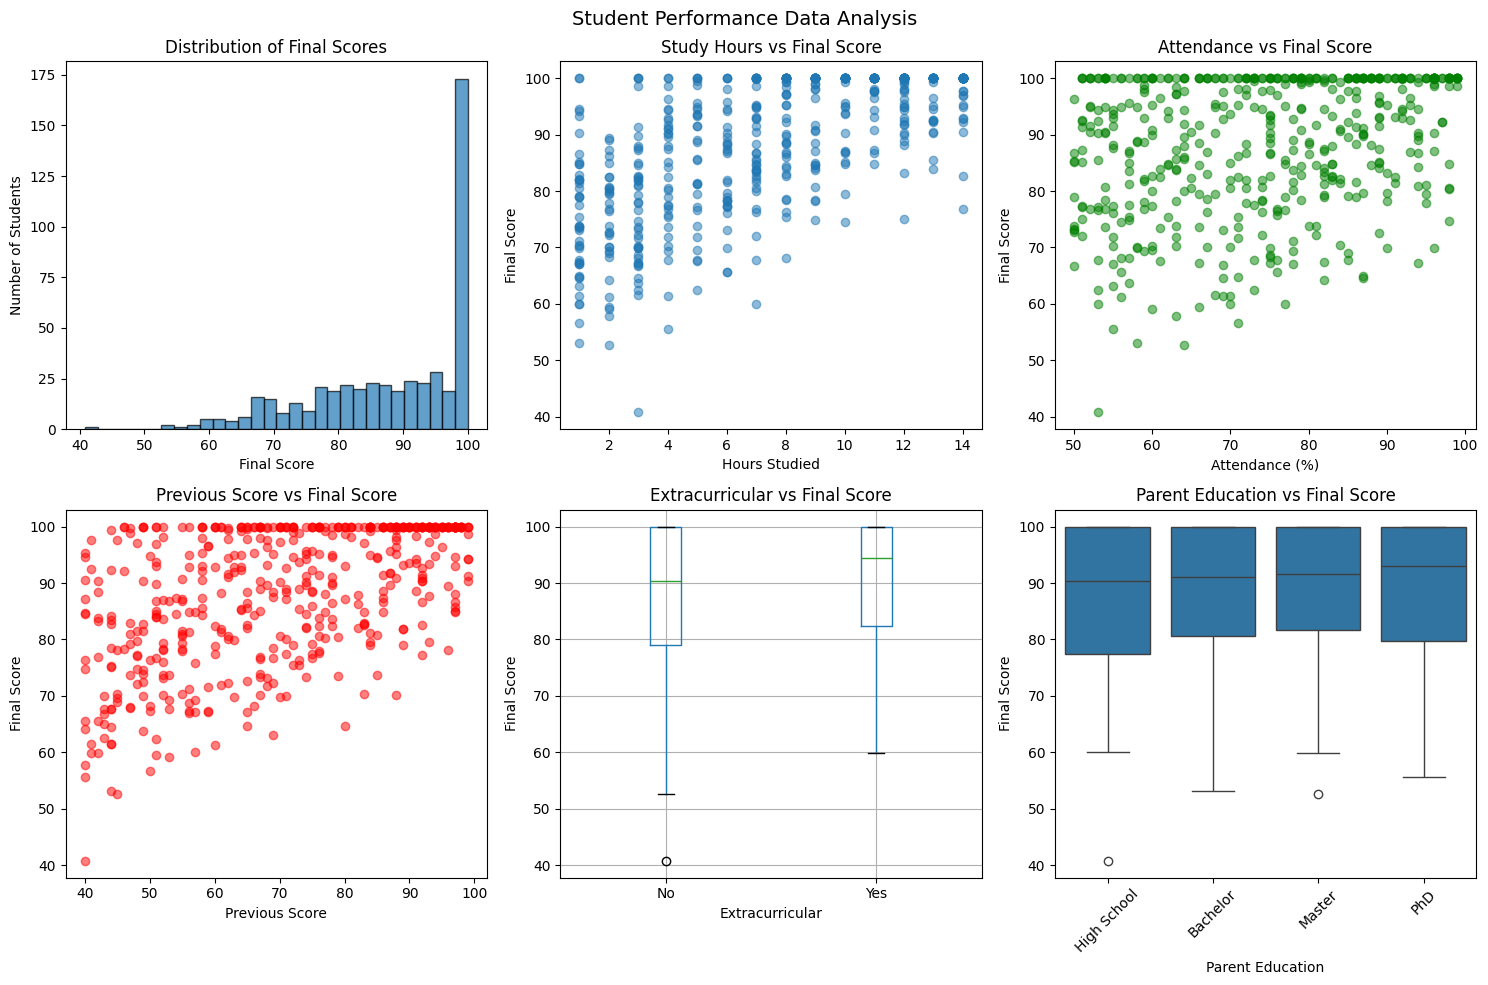


📊 Key Observations:
1. Final scores roughly follow a normal distribution
2. More study hours generally increase scores
3. Attendance strongly affects performance
4. Extracurricular students perform slightly better
5. Parent education has some correlation with results


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 500

# Generate dataset
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# Create final score (target variable)
df_students['final_score'] = (
    df_students['hours_studied'] * 2.5 +
    df_students['previous_score'] * 0.5 +
    df_students['attendance'] * 0.3 +
    df_students['sleep_hours'] * 1.5 +
    (df_students['extracurricular'] == 'Yes') * 5 +
    (df_students['internet_access'] == 'Yes') * 3 +
    np.random.normal(0, 5, n_students)
).clip(0, 100).round(2)

# Basic info
print("✅ Synthetic Student Dataset Created!")
print("Dataset Shape:", df_students.shape)
print("Number of Students:", len(df_students))
print("Features:", df_students.columns.tolist())

print("\nFirst 10 rows:")
print(df_students.head(10))

print("\nStatistical Summary:")
print(df_students.describe())

# ---------------- VISUALIZATION ----------------

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of final scores
axes[0, 0].hist(df_students['final_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Final Scores')
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Number of Students')

# 2. Study hours vs Final Score
axes[0, 1].scatter(df_students['hours_studied'], df_students['final_score'], alpha=0.5)
axes[0, 1].set_title('Study Hours vs Final Score')
axes[0, 1].set_xlabel('Hours Studied')
axes[0, 1].set_ylabel('Final Score')

# 3. Attendance vs Final Score
axes[0, 2].scatter(df_students['attendance'], df_students['final_score'], alpha=0.5, color='green')
axes[0, 2].set_title('Attendance vs Final Score')
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Final Score')

# 4. Previous Score vs Final Score
axes[1, 0].scatter(df_students['previous_score'], df_students['final_score'], alpha=0.5, color='red')
axes[1, 0].set_title('Previous Score vs Final Score')
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Final Score')

# 5. Box plot - Extracurricular vs Final Score
df_students.boxplot(column='final_score', by='extracurricular', ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular vs Final Score')
axes[1, 1].set_xlabel('Extracurricular')
axes[1, 1].set_ylabel('Final Score')

# 6. Parent Education vs Final Score
education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(
    x='parent_education',
    y='final_score',
    data=df_students,
    order=education_order,
    ax=axes[1, 2]
)

axes[1, 2].set_title('Parent Education vs Final Score')
axes[1, 2].set_xlabel('Parent Education')
axes[1, 2].set_ylabel('Final Score')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Student Performance Data Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Key observations
print("\n📊 Key Observations:")
print("1. Final scores roughly follow a normal distribution")
print("2. More study hours generally increase scores")
print("3. Attendance strongly affects performance")
print("4. Extracurricular students perform slightly better")
print("5. Parent education has some correlation with results")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

print("="*60)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*60)

# 1. Missing values check
print("\n1. Checking for missing values:")
print(df_students.isnull().sum())

# 2. Encode categorical variables
print("\n2. Converting categorical variables:")
label_encoders = {}

categorical_cols = ['extracurricular', 'parent_education', 'internet_access']

for col in categorical_cols:
    le = LabelEncoder()
    df_students[col + '_encoded'] = le.fit_transform(df_students[col])
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("   ", col, ":", mapping)
    
    label_encoders[col] = le

# 3. Feature selection
feature_cols = [
    'hours_studied',
    'previous_score',
    'attendance',
    'sleep_hours',
    'extracurricular_encoded',
    'internet_access_encoded',
    'parent_education_encoded'
]

target_col = 'final_score'

print("\n3. Features for ML:")
for col in feature_cols:
    print("   -", col)

print("   Target:", target_col)

# 4. Correlation analysis
print("\n4. Correlation with target:")
correlations = df_students[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)

for feature, corr in correlations.items():
    if feature != target_col:
        print("   ", feature, ":", round(corr, 3))

PREPARING DATA FOR MACHINE LEARNING

1. Checking for missing values:
student_id          0
hours_studied       0
previous_score      0
attendance          0
sleep_hours         0
extracurricular     0
parent_education    0
internet_access     0
final_score         0
dtype: int64

2. Converting categorical variables:
    extracurricular : {'No': np.int64(0), 'Yes': np.int64(1)}
    parent_education : {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3)}
    internet_access : {'No': np.int64(0), 'Yes': np.int64(1)}

3. Features for ML:
   - hours_studied
   - previous_score
   - attendance
   - sleep_hours
   - extracurricular_encoded
   - internet_access_encoded
   - parent_education_encoded
   Target: final_score

4. Correlation with target:
    hours_studied : 0.66
    previous_score : 0.528
    attendance : 0.288
    sleep_hours : 0.176
    extracurricular_encoded : 0.124
    internet_access_encoded : 0.101
    parent_education_encoded : 0.0

In [ ]:
# Save the processed dataset
df_students.to_csv('student_performance.csv', index=False)
print("✅ Dataset saved as 'student_performance.csv'")

# Also save preprocessed data (ready for ML)
ml_ready_data = df_students[feature_cols + [target_col]]
ml_ready_data.to_csv('student_performance_ml_ready.csv', index=False)
print("✅ ML-ready dataset saved as 'student_performance_ml_ready.csv'")

# Save feature information for Day 2
import json
feature_info = {
    'feature_columns': feature_cols,
    'target_column': target_col,
    'categorical_mappings': {}
}

for col, le in label_encoders.items():
    feature_info['categorical_mappings'][col] = dict(zip(le.classes_, le.transform(le.classes_)))

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print("✅ Feature information saved as 'feature_info.json'")

print("\n📁 Files created for Day 2:")
print("   1. student_performance.csv - Raw dataset")
print("   2. student_performance_ml_ready.csv - Preprocessed for ML")
print("   3. feature_info.json - Feature names and mappings")

✅ Dataset saved as 'student_performance.csv'
✅ ML-ready dataset saved as 'student_performance_ml_ready.csv'


TypeError: Object of type int64 is not JSON serializable